In [1]:
import matplotlib.pyplot as plt
import scipp as sc
from trex.instrument import Instrument
import scipp.constants as const
from scippneutron.tof import chopper_cascade

T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(2.5, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode


trex = Instrument(wavelength=central_wavelength, rrm=rrm, mode=mode, t_offset=T_OFFSET)
res = trex.model.run()

# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["Monitor at Sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]

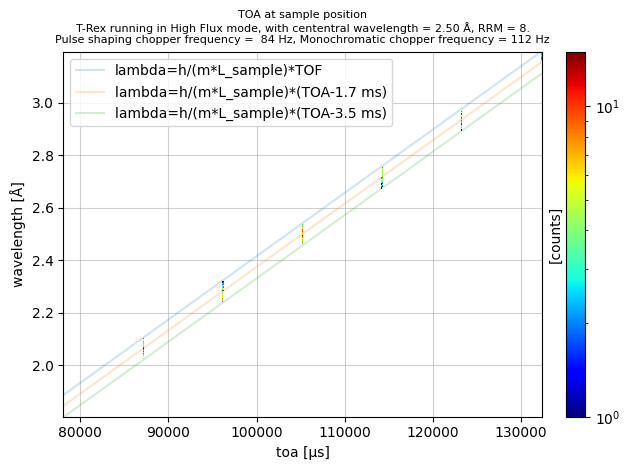

In [2]:
fig, ax = plt.subplots()
# tof_sample = events_at_sample.hist(wavelength=200, tof=500).plot(norm='log', ax=ax)
toa_sample = events_at_sample.hist(wavelength=800, toa=1500).plot(
    norm="log", cbar=True, ax=ax, cmap="jet"
)
ax.set_title("TOA at sample position\n" + str(trex), fontsize=8)
# TOF line
line_tof = sc.linspace("tof", 70, 140, 100, unit="ms").to(unit="us")
line_wavelength_tof = (
    const.h / const.m_n / trex.monitors["Monitor at Sample"].distance * line_tof
).to(unit="Å")
ax.plot(line_tof, line_wavelength_tof, label="lambda=h/(m*L_sample)*TOF", alpha=0.2)

# # TOA line
line_toa = sc.linspace("toa", 70, 140, 100, unit="ms").to(unit="us")
line_wavelength_toa = (
    const.h
    / const.m_n
    / trex.monitors["Monitor at Sample"].distance
    * (line_toa - T_OFFSET.to(unit="us"))
).to(unit="Å")
ax.plot(
    line_toa, line_wavelength_toa, label="lambda=h/(m*L_sample)*(TOA-1.7 ms)", alpha=0.2
)

line_wavelength_toa = (
    const.h
    / const.m_n
    / trex.monitors["Monitor at Sample"].distance
    * (line_toa - sc.scalar(3.5, unit="ms").to(unit="us"))
).to(unit="Å")
ax.plot(
    line_toa, line_wavelength_toa, label="lambda=h/(m*L_sample)*(TOA-3.5 ms)", alpha=0.2
)

ax.legend()
ax.grid(alpha=0.6)
fig.tight_layout()

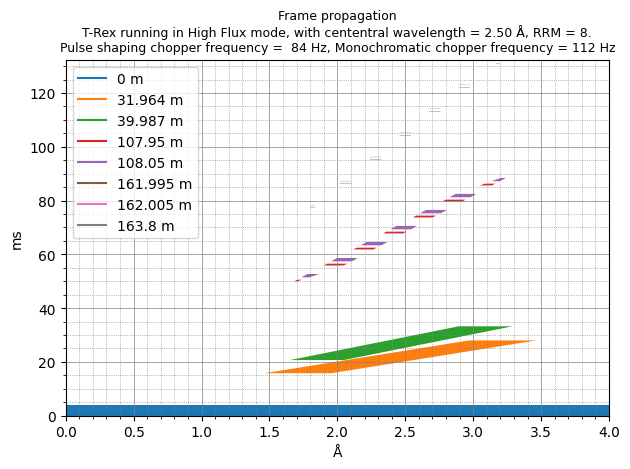

In [3]:
frames = chopper_cascade.FrameSequence.from_source_pulse(
    time_min=sc.scalar(0.0, unit="ms"),
    time_max=sc.scalar(4.0, unit="ms"),  # ESS pulse is 3 ms, but it has a tail
    wavelength_min=sc.scalar(0.0, unit="angstrom"),
    wavelength_max=sc.scalar(4.0, unit="angstrom"),
)
frames = frames.chop(trex.chopper_cascade.values())
at_sample = frames.propagate_to(trex.monitors["Monitor at Sample"].distance)

fig, ax = at_sample.draw(transpose=True)
ax.set_title("Frame propagation\n" + str(trex), fontsize=9)
ax.legend()
fig.tight_layout()

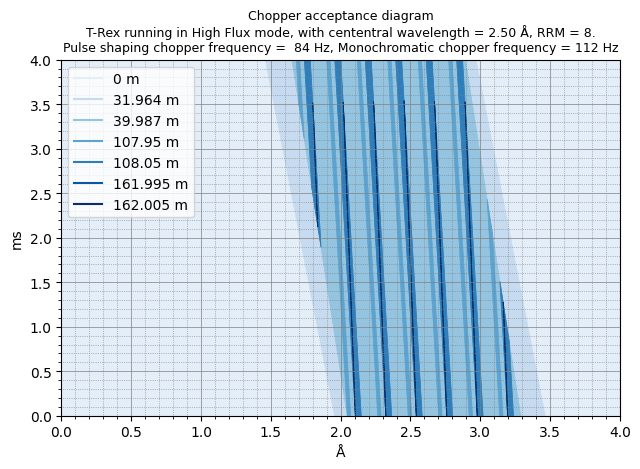

In [4]:
fig, ax = frames.acceptance_diagram()
ax.set_title("Chopper acceptance diagram\n" + str(trex), fontsize=9)
ax.legend()
fig.tight_layout()

In [5]:
from scippneutron.tof.chopper_cascade import FrameSequence
from dataclasses import dataclass


@dataclass
class SubframeVertex:
    distance: sc.Variable
    time: sc.Variable
    wavelength: sc.Variable


def acceptance_paths(
    *,
    frames: FrameSequence,
    time_unit: str = 'ms',
    wavelength_unit: str = 'angstrom',
) -> dict[str, dict]:
    frame_paths = {}
    for i, frame in enumerate(frames):
        subframe_paths = []
        for isub, subframe in enumerate(frame.subframes):
            vertex = SubframeVertex(
                distance=frame.distance,
                time = subframe.time.to(unit=time_unit, copy=False),
                wavelength = subframe.wavelength.to(unit=wavelength_unit, copy=False)
            )
            subframe_paths.append(vertex)
        frame_paths[f"{frame.distance:c}"] = subframe_paths
    return frame_paths

In [6]:
display(acceptance_paths(frames=frames).keys())
subframe_vertexes = acceptance_paths(frames=frames)
subframe_vertexes['162.005 m']

dict_keys(['0 m', '31.964 m', '39.987 m', '107.95 m', '108.05 m', '161.995 m', '162.005 m'])

[SubframeVertex(distance=<scipp.Variable> ()    float64              [m]  162.005, time=<scipp.Variable> (vertex: 4)    float64             [ms]  [77.2394, 77.3443, 77.3444, 77.2394], wavelength=<scipp.Variable> (vertex: 4)    float64             [Å]  [1.8003, 1.80798, 1.83684, 1.83343]),
 SubframeVertex(distance=<scipp.Variable> ()    float64              [m]  162.005, time=<scipp.Variable> (vertex: 5)    float64             [ms]  [95.0965, 95.2025, ..., 95.1349, 95.0965], wavelength=<scipp.Variable> (vertex: 5)    float64             [Å]  [2.23593, 2.24369, ..., 2.32312, 2.3203]),
 SubframeVertex(distance=<scipp.Variable> ()    float64              [m]  162.005, time=<scipp.Variable> (vertex: 5)    float64             [ms]  [86.168, 86.2734, ..., 86.2102, 86.168], wavelength=<scipp.Variable> (vertex: 5)    float64             [Å]  [2.01812, 2.02584, ..., 2.10519, 2.10209]),
 SubframeVertex(distance=<scipp.Variable> ()    float64              [m]  162.005, time=<scipp.Variable> (verte

In [7]:
import tof

source = tof.Source(facility='ess', neutrons=50_000_000)
display(source)
source.data

Source:
  pulses=1, neutrons per pulse=50000000
  frequency=14.0 Hz
  facility='ess'
  distance=0.0 m

<scipp.DataArray>
Dimensions: Sizes[pulse:1, event:50000000, ]
Coordinates:
* birth_time                float64            [µs]  (pulse, event)  [274.368, 3089.94, ..., 2964.4, 1238.04]
* distance                  float64              [m]  ()  0
* eto                       float64            [µs]  (pulse, event)  [274.368, 3089.94, ..., 2964.4, 1238.04]
* id                          int64        <no unit>  (pulse, event)  [0, 1, ..., 49999998, 49999999]
* speed                     float64            [m/s]  (pulse, event)  [6032.4, 2888.71, ..., 3907.74, 806.999]
* toa                       float64            [µs]  (pulse, event)  [274.368, 3089.94, ..., 2964.4, 1238.04]
* wavelength                float64             [Å]  (pulse, event)  [0.655798, 1.36948, ..., 1.01236, 4.90215]
Data:
                            float64         [counts]  (pulse, event)  [1, 1, ..., 1, 1]

In [8]:
birth_time_limit = sc.scalar(40., unit='µs')
wavelength_limit = sc.scalar(4., unit='angstrom')

binned = source.data.squeeze().bin(birth_time=100, wavelength=100)['birth_time', :birth_time_limit]['wavelength', :wavelength_limit]
binned = binned.bin(birth_time=100, wavelength=200)
binned

<scipp.DataArray>
Dimensions: Sizes[birth_time:100, wavelength:200, ]
Coordinates:
* birth_time                float64            [µs]  (birth_time [bin-edge])  [12.44, 12.9375, ..., 61.6924, 62.1899]
* distance                  float64              [m]  ()  0
* wavelength                float64             [Å]  (wavelength [bin-edge])  [0.198515, 0.218218, ..., 4.11939, 4.1391]
Data:
                          DataArrayView        <no unit>  (birth_time, wavelength)  binned data: dim='event', content=DataArray(
          dims=(event: 62937),
          data=float64[counts],
          coords={'birth_time':float64[µs], 'wavelength':float64[Å], 'speed':float64[m/s],
                  'id':int64, 'eto':float64[µs], 'toa':float64[µs]})

In [9]:
import numpy as np

def get_points(da: sc.DataArray, *, xcoord_name: str = 'wavelength', ycoord_name: str = 'birth_time') -> np.ndarray:
    x_coord = da.coords[xcoord_name] if not da.coords.is_edges(xcoord_name) else sc.midpoints(da.coords[xcoord_name])
    y_coord = da.coords[ycoord_name] if not da.coords.is_edges(ycoord_name) else sc.midpoints(da.coords[ycoord_name])
    sizes = {**x_coord.sizes, **y_coord.sizes}
    x_coord = x_coord.broadcast(sizes=sizes).copy(deep=True)
    y_coord = y_coord.broadcast(sizes=sizes).copy(deep=True)
    # Overwriting unit to make a stack using scipp operator...
    x_coord.unit = 'dimensionless'
    y_coord.unit = 'dimensionless'
    xy_stack = sc.concat([x_coord, y_coord], dim='i').flatten(dims=sizes.keys(), to='pos').transpose()
    return xy_stack.values

In [10]:
example_vertex = subframe_vertexes['31.964 m'][0]
example_vertex

SubframeVertex(distance=<scipp.Variable> ()    float64              [m]  31.964, time=<scipp.Variable> (vertex: 4)    float64             [ms]  [15.8083, 27.9908, 27.9908, 15.8083], wavelength=<scipp.Variable> (vertex: 4)    float64             [Å]  [1.46145, 2.96923, 3.46429, 1.95651])

In [11]:
from matplotlib.path import Path 
import numpy as np

def mask_paths(*, da: sc.DataArray, vertex: SubframeVertex) -> sc.DataArray:
    wav_time_points = get_points(da)
    vx = vertex.wavelength.values
    vy = vertex.time.values
    verts = np.column_stack([vx, vy])
    path = Path(verts)
    sizes = da.sizes
    dims = sizes.keys()
    inside = sc.array(
        dims=dims,
        values=path.contains_points(wav_time_points).reshape(tuple(sizes.values())),
    )
    return da.assign_masks({f"{vertex.distance:c}": ~inside})


masked = mask_paths(da=binned, vertex=example_vertex)
masked

<scipp.DataArray>
Dimensions: Sizes[birth_time:100, wavelength:200, ]
Coordinates:
* birth_time                float64            [µs]  (birth_time [bin-edge])  [12.44, 12.9375, ..., 61.6924, 62.1899]
* distance                  float64              [m]  ()  0
* wavelength                float64             [Å]  (wavelength [bin-edge])  [0.198515, 0.218218, ..., 4.11939, 4.1391]
Data:
                          DataArrayView        <no unit>  (birth_time, wavelength)  binned data: dim='event', content=DataArray(
          dims=(event: 62937),
          data=float64[counts],
          coords={'birth_time':float64[µs], 'wavelength':float64[Å], 'speed':float64[m/s],
                  'id':int64, 'eto':float64[µs], 'toa':float64[µs]})
Masks:
  31.964 m                     bool        <no unit>  (birth_time, wavelength)  [True, True, ..., True, True]

<scipp.Variable> ()      int64        <no unit>  603

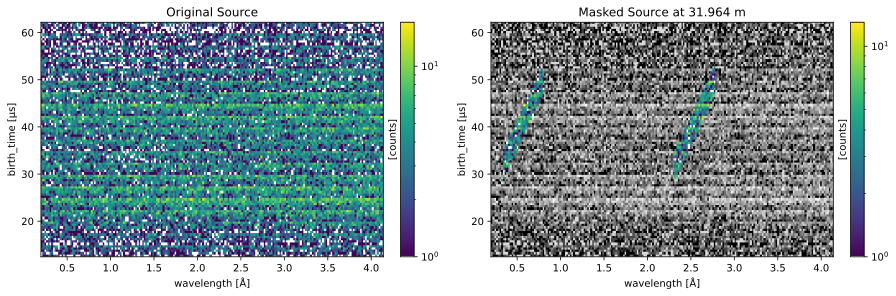

In [12]:
mask_distance = next(iter(masked.masks.keys()))
display((~next(iter(masked.masks.values()))).sum())  # Number of valid bins
plot = (binned.hist().plot(norm='log', title='Original Source') + masked.hist().plot(norm='log', title=f'Masked Source at {mask_distance}'))
plot

# Select Valid Events from the Source

In [13]:
# None masked
display(binned.flatten(to='bin').bins.concat())
# Masked
masked_binned_combined = masked.flatten(to='bin').bins.concat()
masked_binned_combined

<scipp.DataArray>
Dimensions: Sizes[]
Coordinates:
* distance                  float64              [m]  ()  0
Data:
                          DataArrayView        <no unit>  ()  binned data: dim='event', content=DataArray(
          dims=(event: 62937),
          data=float64[counts],
          coords={'birth_time':float64[µs], 'wavelength':float64[Å], 'speed':float64[m/s],
                  'id':int64, 'eto':float64[µs], 'toa':float64[µs]})

<scipp.DataArray>
Dimensions: Sizes[]
Coordinates:
* distance                  float64              [m]  ()  0
Data:
                          DataArrayView        <no unit>  ()  binned data: dim='event', content=DataArray(
          dims=(event: 2080),
          data=float64[counts],
          coords={'birth_time':float64[µs], 'wavelength':float64[Å], 'speed':float64[m/s],
                  'id':int64, 'eto':float64[µs], 'toa':float64[µs]})

In [14]:
selected_events = masked_binned_combined.values
selected_events

<scipp.DataArray>
Dimensions: Sizes[event:2080, ]
Coordinates:
* birth_time                float64            [µs]  (event)  [42.4928, 42.3086, ..., 19.2355, 24.1579]
* eto                       float64            [µs]  (event)  [42.4928, 42.3086, ..., 19.2355, 24.1579]
* id                          int64        <no unit>  (event)  [3332836, 30937035, ..., 33238319, 36899222]
* speed                     float64            [m/s]  (event)  [2589.48, 2590.67, ..., 1173.78, 1177.32]
* toa                       float64            [µs]  (event)  [42.4928, 42.3086, ..., 19.2355, 24.1579]
* wavelength                float64             [Å]  (event)  [1.52773, 1.52703, ..., 3.37035, 3.36019]
Data:
                            float64         [counts]  (event)  [1, 1, ..., 1, 1]